## 基于日常习惯的健康状态预测系统

### 导包

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams["axes.unicode_minus"] = False  # 正确显示负号

In [ ]:
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

### 读取文件

In [ ]:
df = pd.read_csv('health/health_lifestyle_classification.csv')
y = df.pop('target')
df.pop('survey_code')

### 查看前5行

In [ ]:
df.head()

In [ ]:
y.head()

In [ ]:
df.info()

### 数据预处理

#### 查看缺失值

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(10)

#### 分离数值特征和分类特征

In [ ]:
# 数值型特征
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# 类别型特征
cat_cols = df.select_dtypes(include=['object']).columns.tolist()


#### 分析数值特征

##### 分布图

count    100000.000000
mean          5.004680
std           3.164228
min           0.000000
25%           2.000000
50%           5.000000
75%           8.000000
max          10.000000
Name: mental_health_score, dtype: float64


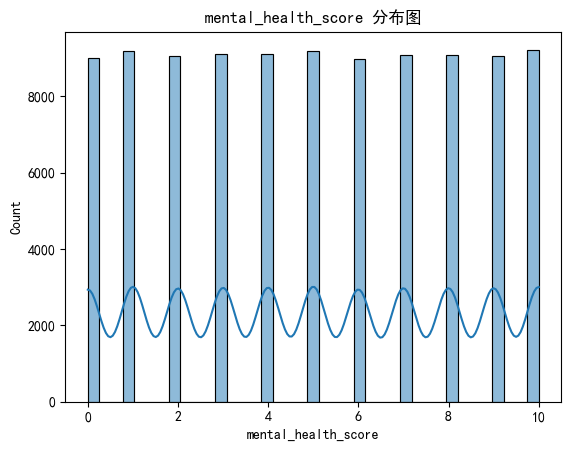

count    91530.000000
mean      4038.127284
std       1930.025678
min        500.000000
25%       2665.402843
50%       4004.601345
75%       5360.012694
max      12029.409353
Name: income, dtype: float64


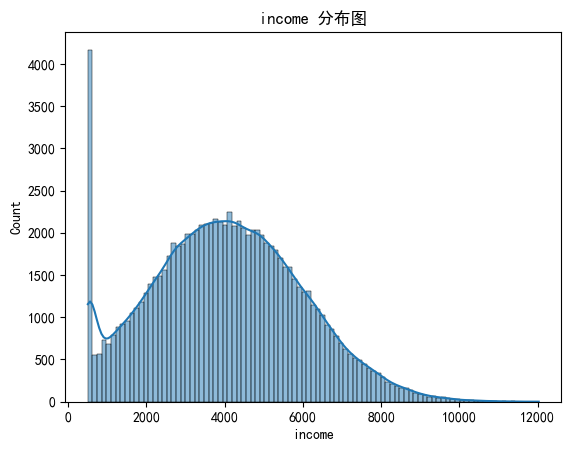

count    100000.000000
mean          2.998720
std           1.414786
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: meals_per_day, dtype: float64


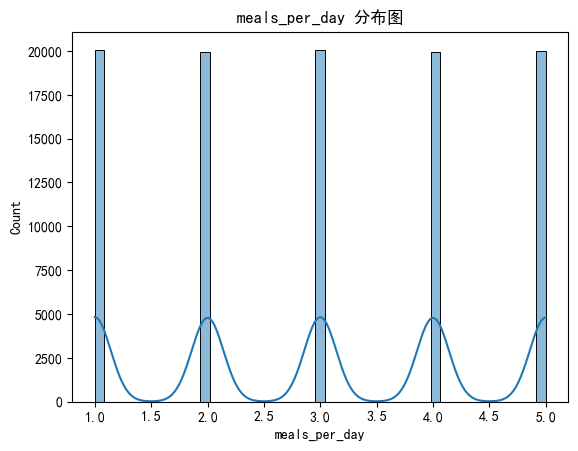

count    100000.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: electrolyte_level, dtype: float64


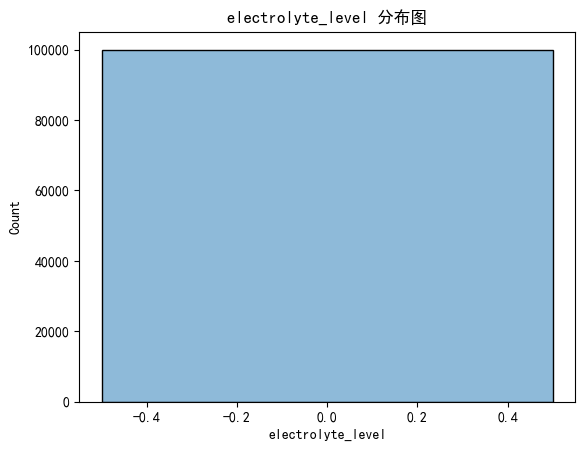

count    89526.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: gene_marker_flag, dtype: float64


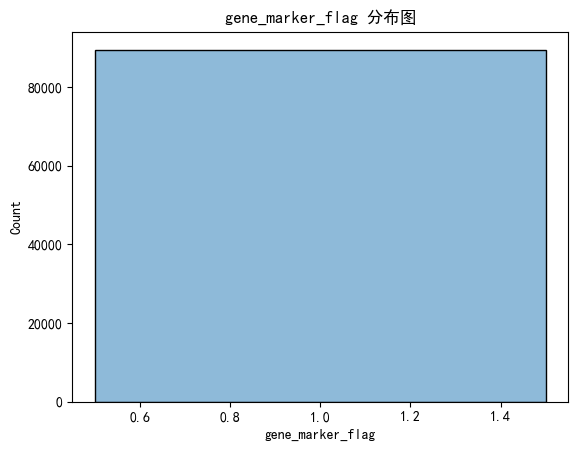

count    100000.0
mean          5.5
std           0.0
min           5.5
25%           5.5
50%           5.5
75%           5.5
max           5.5
Name: environmental_risk_score, dtype: float64


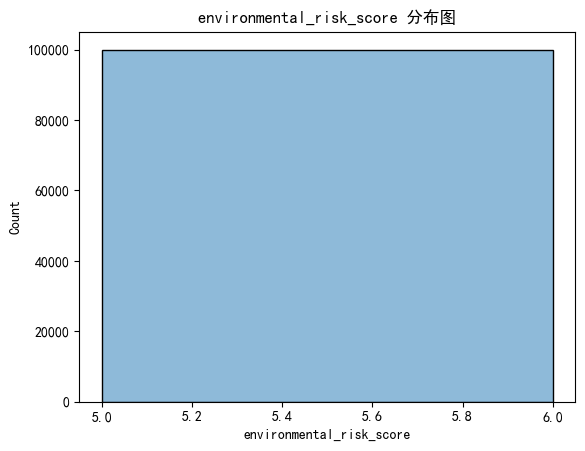

count    100000.000000
mean          0.015726
std           5.764489
min          -9.999895
25%          -4.980501
50%           0.015589
75%           5.008424
max           9.999966
Name: daily_supplement_dosage, dtype: float64


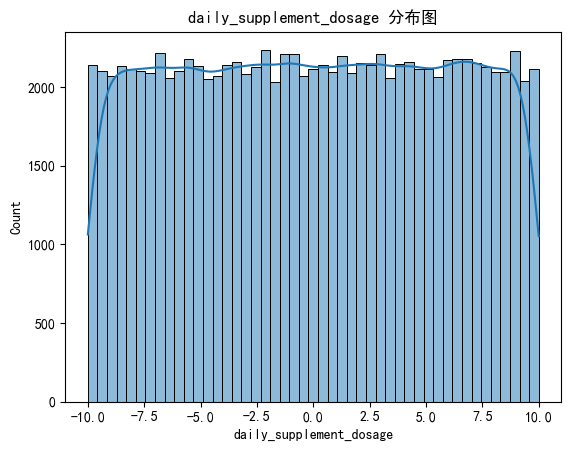

In [79]:
def summary_numeric(col):
    print(df[col].describe())
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} 分布图")
    plt.show()

for col in num_cols:
    summary_numeric(col)

##### 箱线图

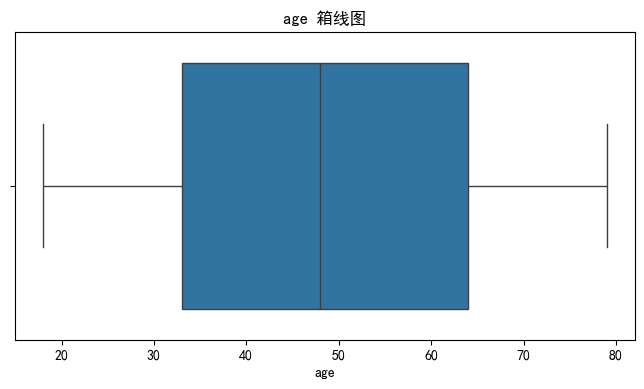

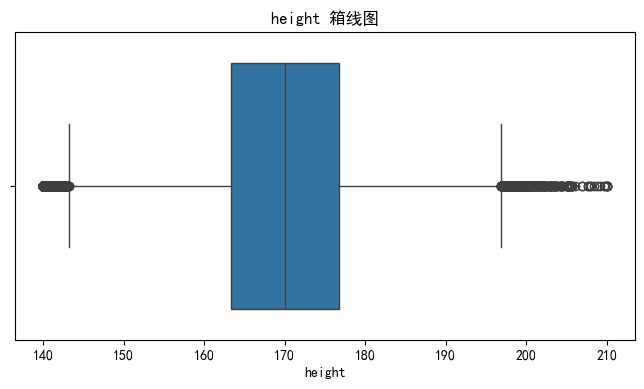

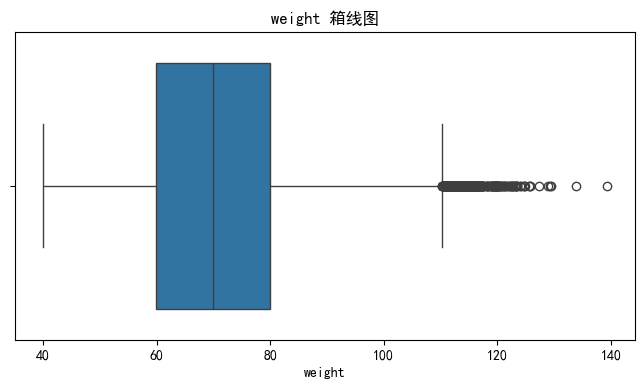

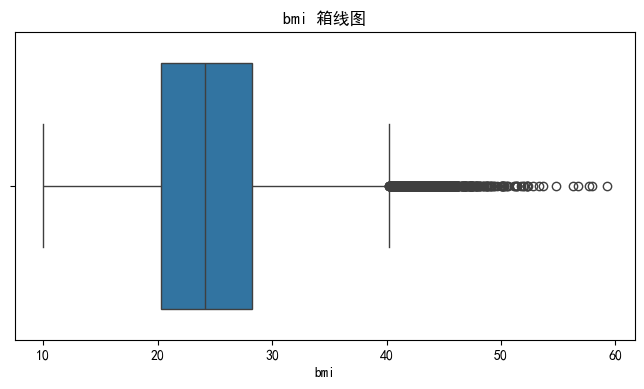

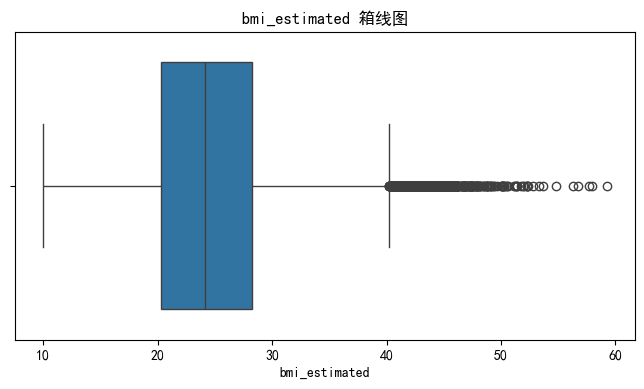

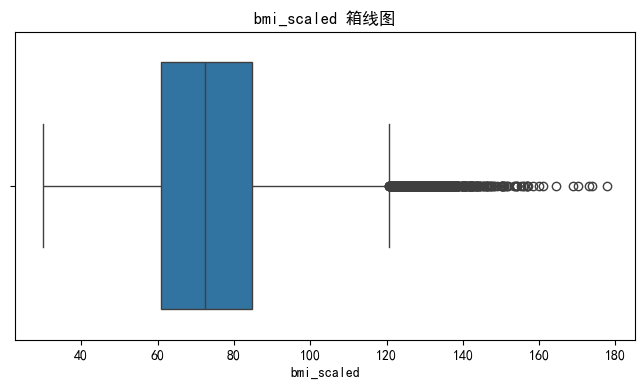

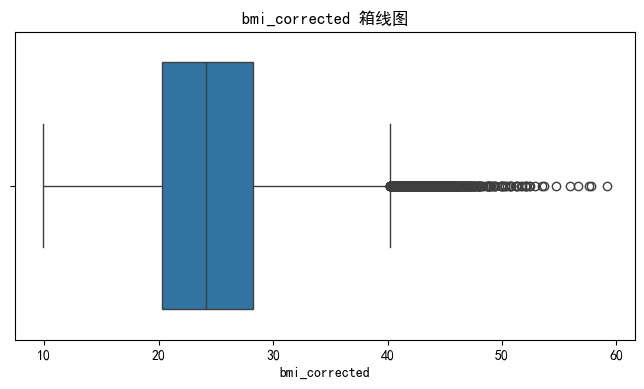

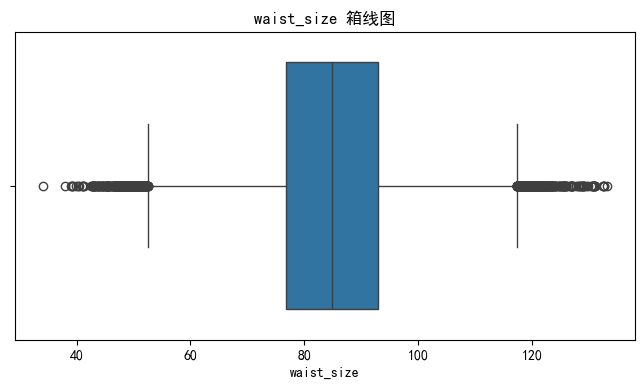

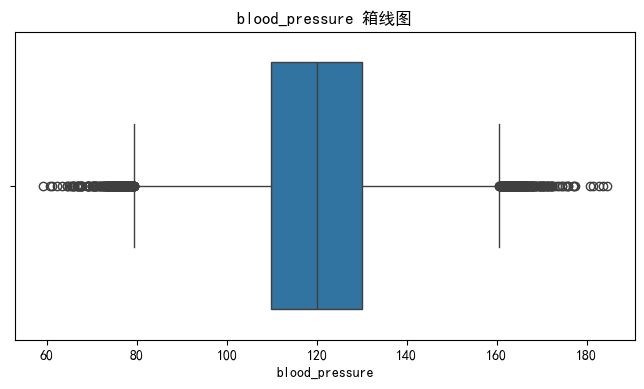

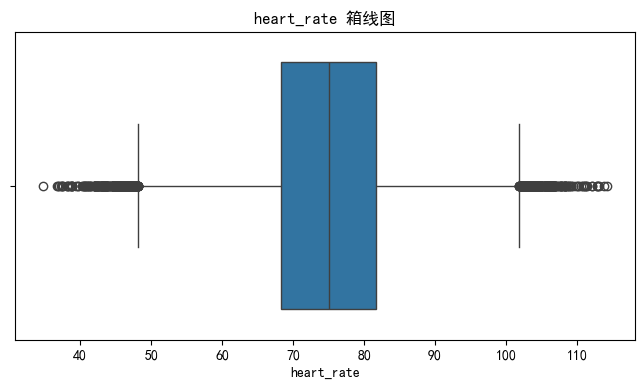

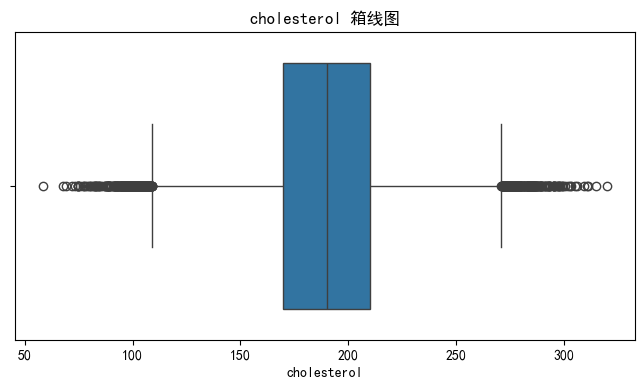

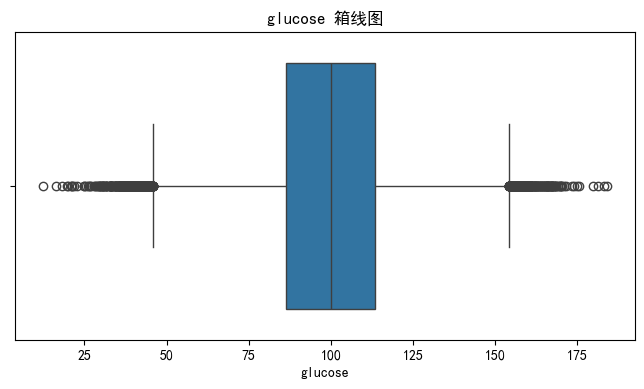

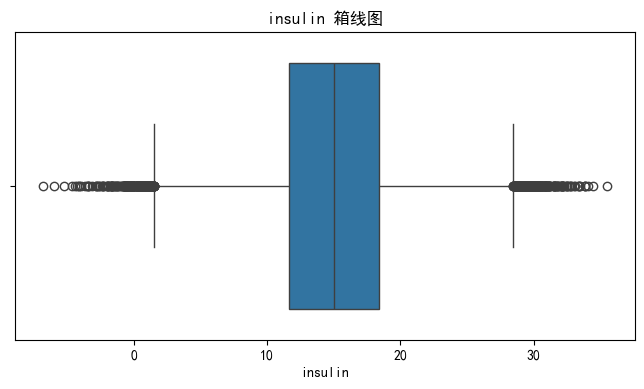

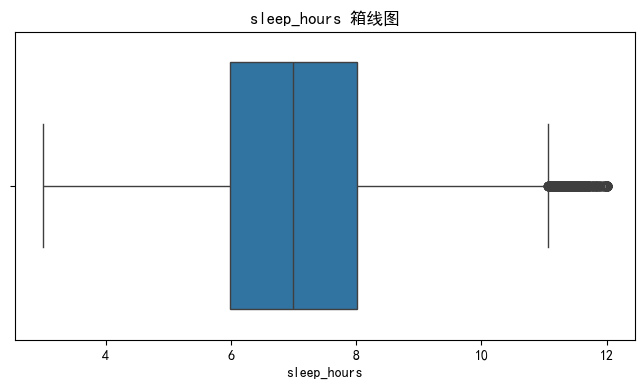

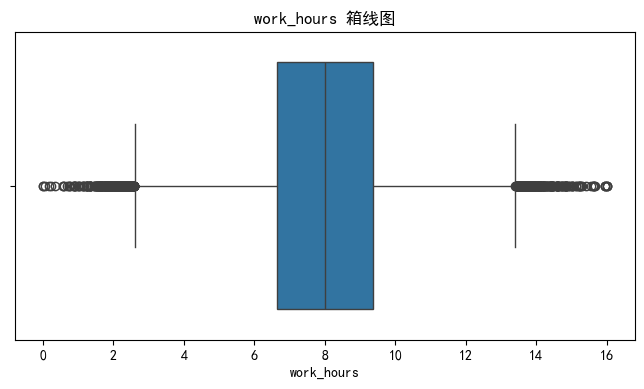

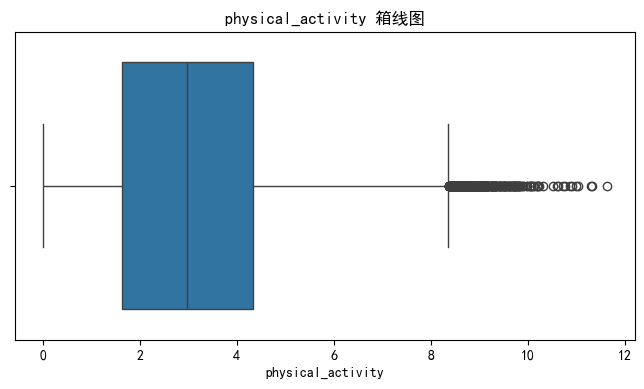

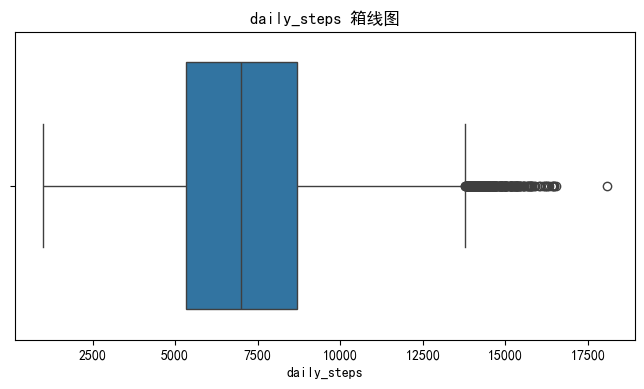

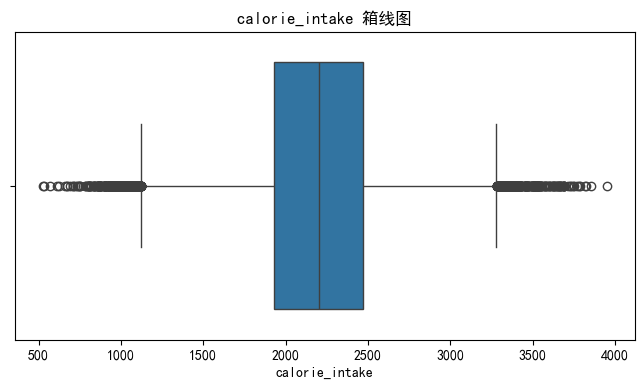

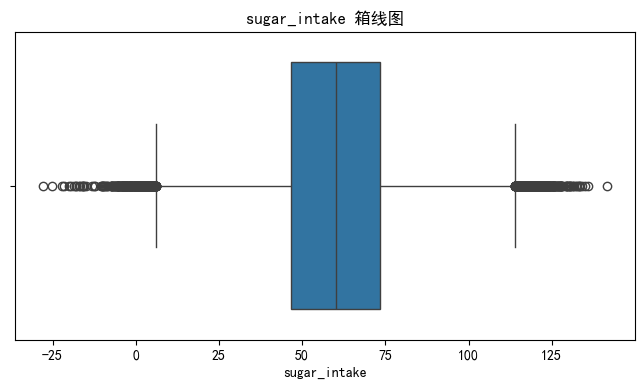

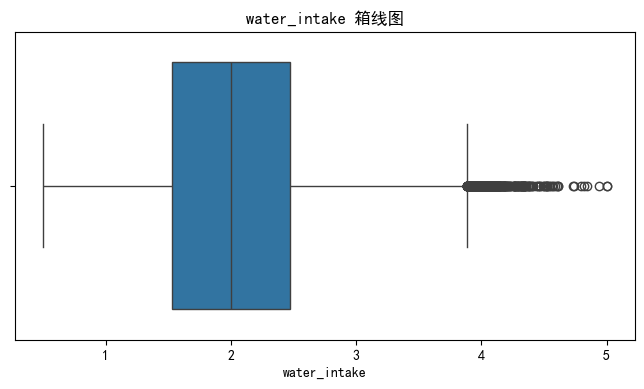

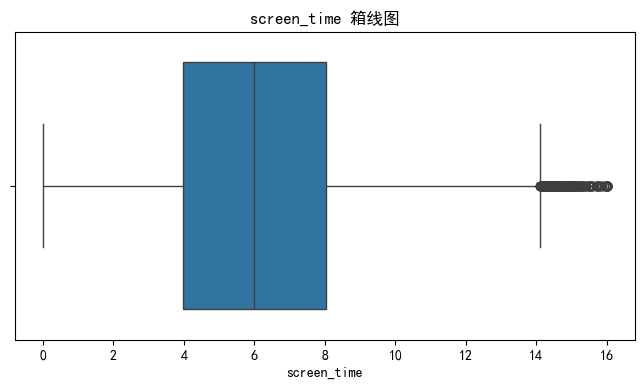

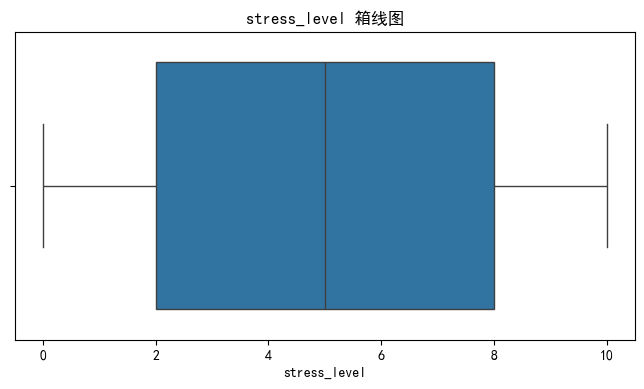

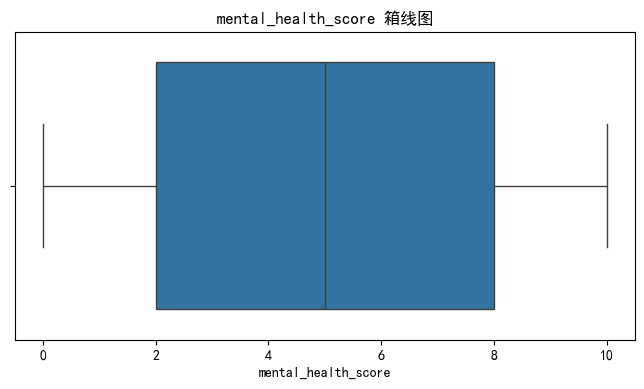

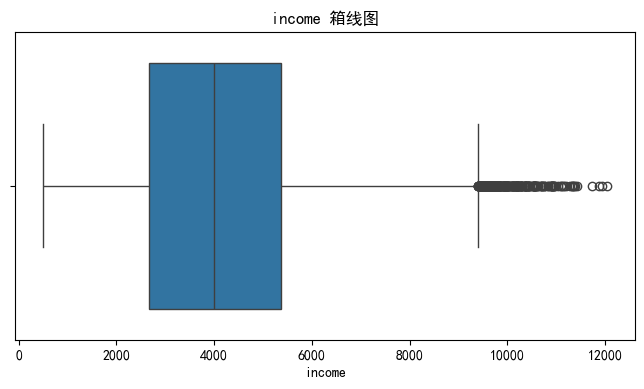

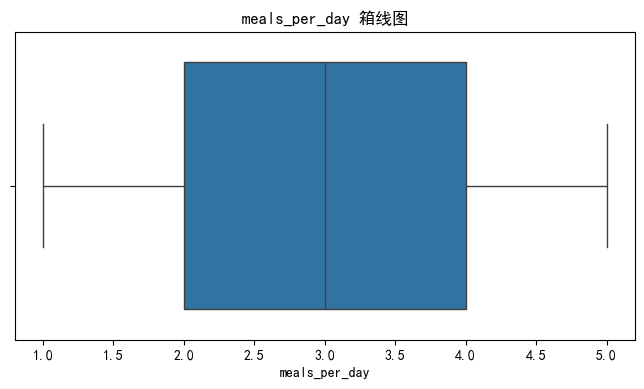

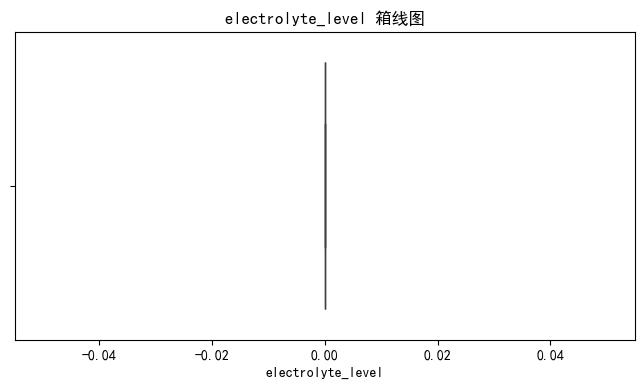

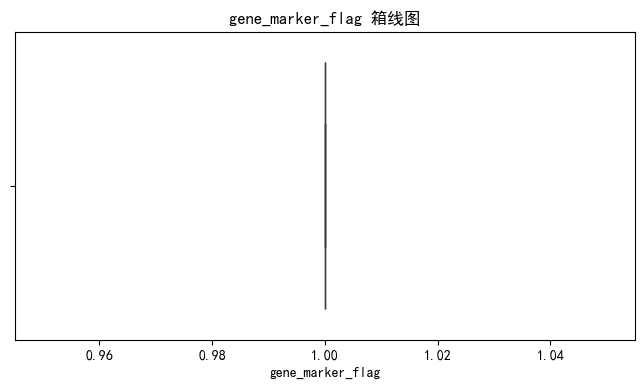

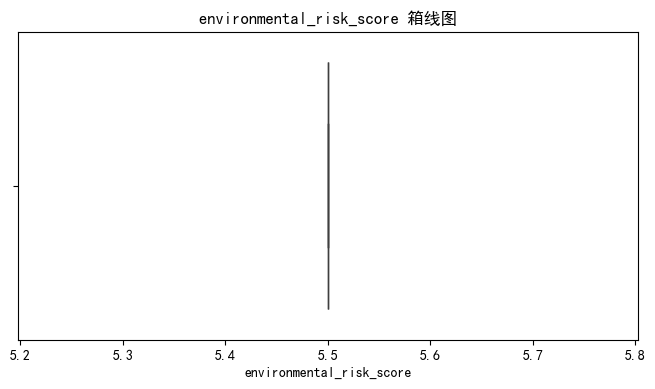

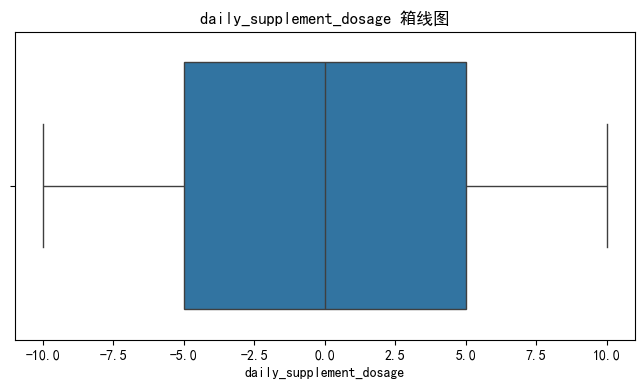

In [80]:
def boxplot_numeric(col):
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} 箱线图")
    plt.show()

for col in num_cols:
    boxplot_numeric(col)


##### 删除低方差列

In [81]:
# 设定方差阈值
from sklearn.feature_selection import VarianceThreshold

var_thresh = VarianceThreshold(threshold=0.1)
var_thresh.fit(df[num_cols])
# 选择高方差特征
high_var_features = df[num_cols].columns[var_thresh.get_support()]
print('删除低方差列之前的列数',len(num_cols))
print('删除低方差列之后的列数',len(high_var_features))

删除低方差列之前的列数 29
删除低方差列之后的列数 26


In [82]:
num_cols

['age',
 'height',
 'weight',
 'bmi',
 'bmi_estimated',
 'bmi_scaled',
 'bmi_corrected',
 'waist_size',
 'blood_pressure',
 'heart_rate',
 'cholesterol',
 'glucose',
 'insulin',
 'sleep_hours',
 'work_hours',
 'physical_activity',
 'daily_steps',
 'calorie_intake',
 'sugar_intake',
 'water_intake',
 'screen_time',
 'stress_level',
 'mental_health_score',
 'income',
 'meals_per_day',
 'electrolyte_level',
 'gene_marker_flag',
 'environmental_risk_score',
 'daily_supplement_dosage']

In [83]:
high_var_features

Index(['age', 'height', 'weight', 'bmi', 'bmi_estimated', 'bmi_scaled',
       'bmi_corrected', 'waist_size', 'blood_pressure', 'heart_rate',
       'cholesterol', 'glucose', 'insulin', 'sleep_hours', 'work_hours',
       'physical_activity', 'daily_steps', 'calorie_intake', 'sugar_intake',
       'water_intake', 'screen_time', 'stress_level', 'mental_health_score',
       'income', 'meals_per_day', 'daily_supplement_dosage'],
      dtype='object')

##### 处理离群值

In [84]:
def outlier_thresholds(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

def check_outliers(data, col):
    lower, upper = outlier_thresholds(data, col)
    return data[(data[col] < lower) | (data[col] > upper)]

for col in high_var_features:
    print(f"{col} 异常值数量:", len(check_outliers(df, col)))

age 异常值数量: 0
height 异常值数量: 750
weight 异常值数量: 335
bmi 异常值数量: 936
bmi_estimated 异常值数量: 936
bmi_scaled 异常值数量: 936
bmi_corrected 异常值数量: 937
waist_size 异常值数量: 706
blood_pressure 异常值数量: 591
heart_rate 异常值数量: 612
cholesterol 异常值数量: 677
glucose 异常值数量: 680
insulin 异常值数量: 571
sleep_hours 异常值数量: 326
work_hours 异常值数量: 618
physical_activity 异常值数量: 341
daily_steps 异常值数量: 307
calorie_intake 异常值数量: 730
sugar_intake 异常值数量: 688
water_intake 异常值数量: 348
screen_time 异常值数量: 339
stress_level 异常值数量: 0
mental_health_score 异常值数量: 0
income 异常值数量: 315
meals_per_day 异常值数量: 0
daily_supplement_dosage 异常值数量: 0


In [85]:
def replace_outliers_with_median(data, col):
    lower, upper = outlier_thresholds(data, col)
    median = data[col].median()
    data[col] = np.where((data[col] < lower) | (data[col] > upper), median, data[col])

for col in high_var_features:
    replace_outliers_with_median(df, col)

##### 填补空值

In [86]:
from sklearn.impute import KNNImputer

# 假设 high_var_features 是你要填充的特征列
imputer = KNNImputer(n_neighbors=5)  # 设置 KNN 的邻居数量

# 使用 KNN 填充缺失值
df[high_var_features] = imputer.fit_transform(df[high_var_features])

# 检查填充后的缺失值数量
df[high_var_features].isnull().sum().sort_values(ascending=False).head(10)

age                    0
height                 0
meals_per_day          0
income                 0
mental_health_score    0
stress_level           0
screen_time            0
water_intake           0
sugar_intake           0
calorie_intake         0
dtype: int64

In [87]:
df.isnull().sum().sort_values(ascending=False).head(10)

alcohol_consumption      42387
caffeine_intake          33261
exercise_type            24969
gene_marker_flag         10474
age                          0
mental_health_score          0
mental_health_support        0
education_level              0
job_type                     0
occupation                   0
dtype: int64

##### 绘制初步处理后的分布图和箱线图

count    100000.000000
mean         48.525990
std          17.886768
min          18.000000
25%          33.000000
50%          48.000000
75%          64.000000
max          79.000000
Name: age, dtype: float64


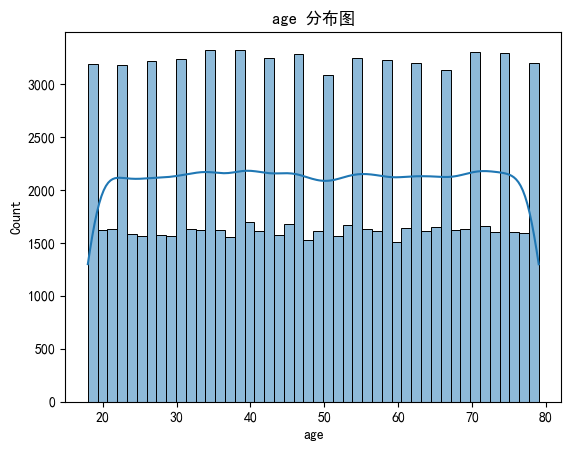

count    100000.000000
mean        170.030716
std           9.648916
min         143.177643
25%         163.423441
50%         170.016778
75%         176.615234
max         196.854326
Name: height, dtype: float64


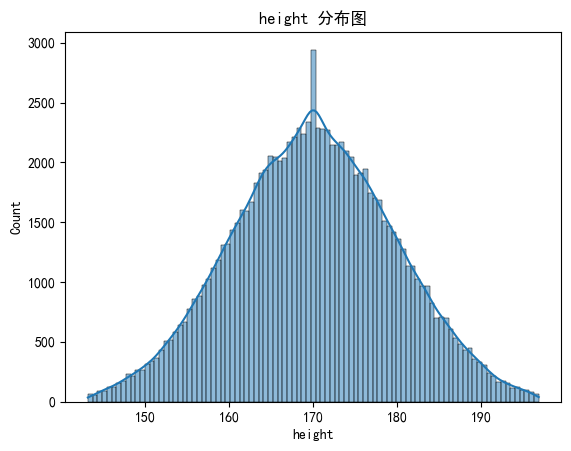

count    100000.000000
mean         69.913677
std          14.458149
min          40.000000
25%          59.856938
50%          69.923976
75%          79.874108
max         110.277510
Name: weight, dtype: float64


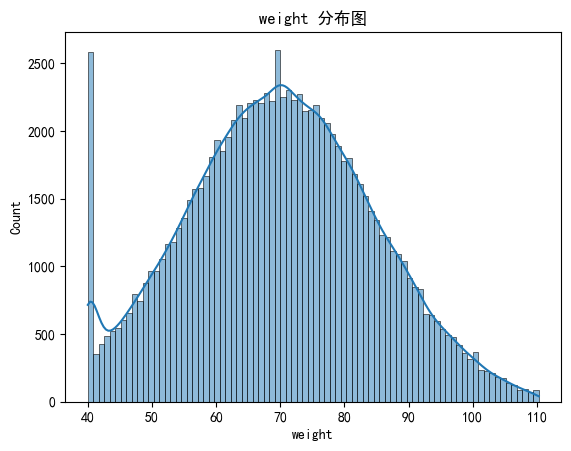

count    100000.000000
mean         24.316338
std           5.662509
min           9.988495
25%          20.271405
50%          24.156661
75%          28.073942
max          40.238257
Name: bmi, dtype: float64


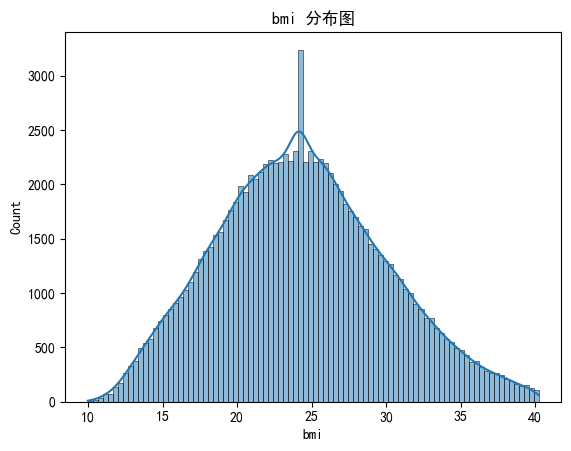

count    100000.000000
mean         24.316338
std           5.662509
min           9.988495
25%          20.271405
50%          24.156661
75%          28.073942
max          40.238257
Name: bmi_estimated, dtype: float64


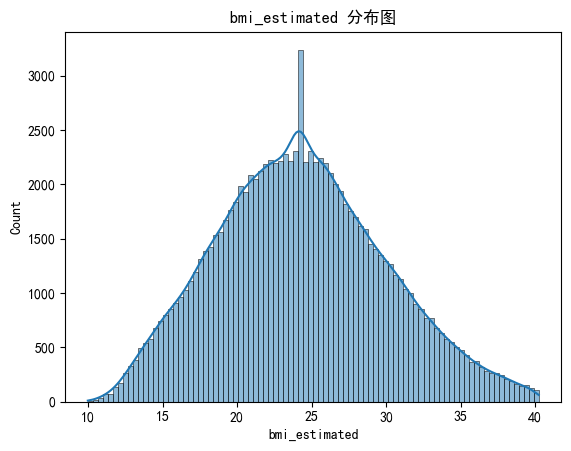

count    100000.000000
mean         72.949013
std          16.987527
min          29.965484
25%          60.814215
50%          72.469982
75%          84.221826
max         120.714770
Name: bmi_scaled, dtype: float64


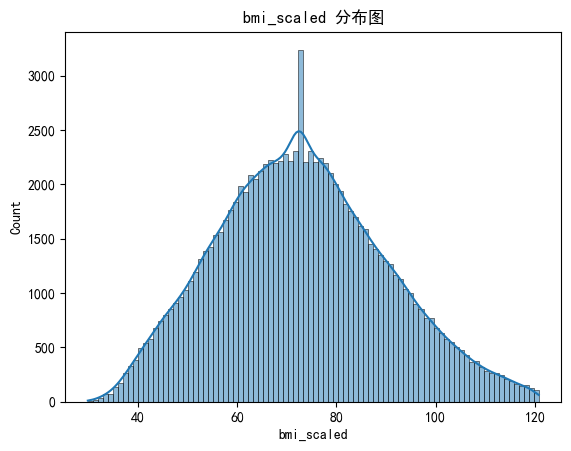

count    100000.000000
mean         24.316307
std           5.665276
min           9.893845
25%          20.271059
50%          24.151611
75%          28.069976
max          40.210679
Name: bmi_corrected, dtype: float64


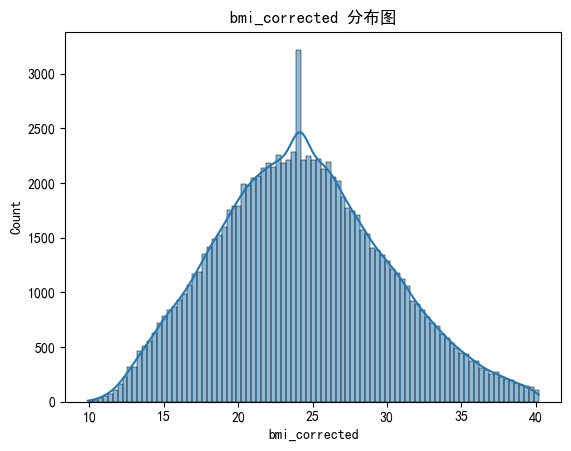

count    100000.000000
mean         84.938193
std          11.648073
min          52.460818
25%          76.944118
50%          84.957139
75%          92.889565
max         117.350587
Name: waist_size, dtype: float64


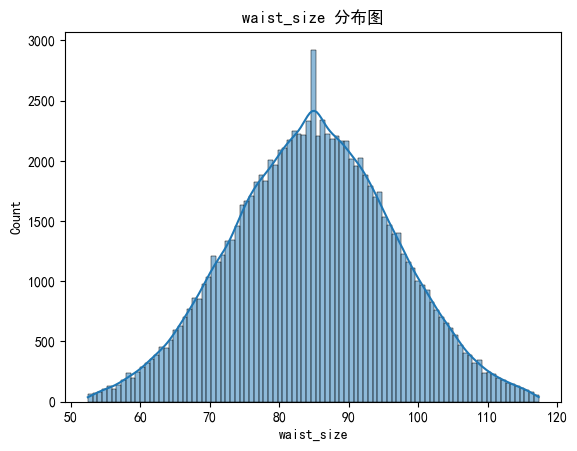

count    100000.000000
mean        119.920720
std          14.115480
min          79.354041
25%         110.609313
50%         119.951794
75%         129.262693
max         160.579138
Name: blood_pressure, dtype: float64


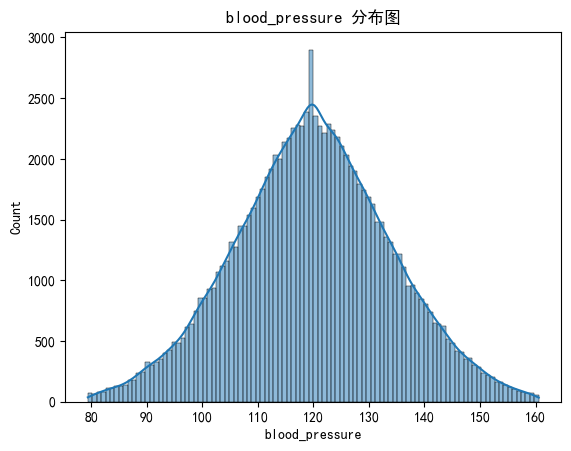

count    100000.000000
mean         74.977824
std           9.069468
min          48.165531
25%          69.177758
50%          75.046211
75%          80.815411
max         101.796722
Name: heart_rate, dtype: float64


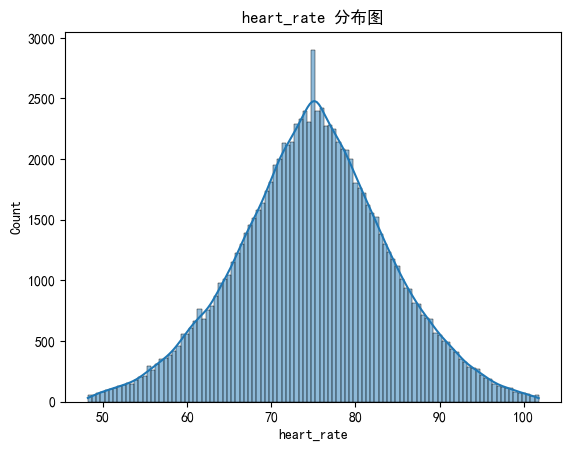

count    100000.000000
mean        190.000458
std          29.037190
min         108.877883
25%         170.020396
50%         190.044579
75%         209.923885
max         271.051076
Name: cholesterol, dtype: float64


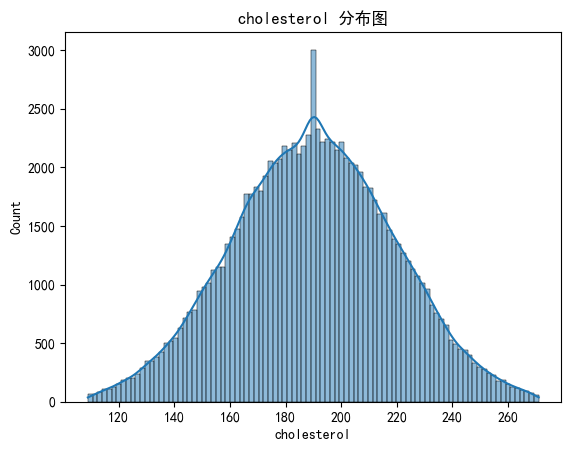

count    100000.000000
mean        100.013416
std          19.354002
min          45.936476
25%          86.666975
50%          99.986834
75%         113.288103
max         154.072129
Name: glucose, dtype: float64


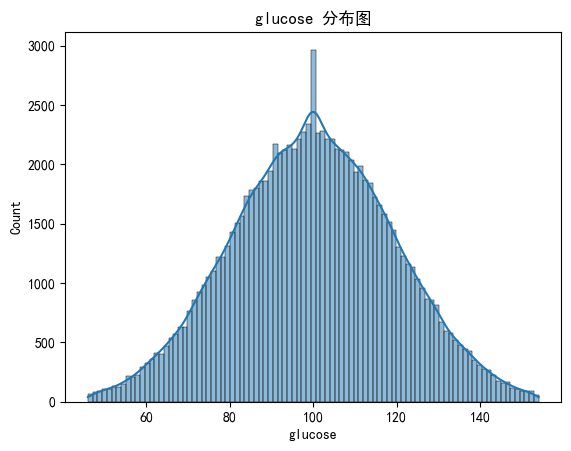

count    100000.000000
mean         14.969530
std           4.530634
min           1.532953
25%          12.089909
50%          14.979372
75%          17.860378
max          28.459451
Name: insulin, dtype: float64


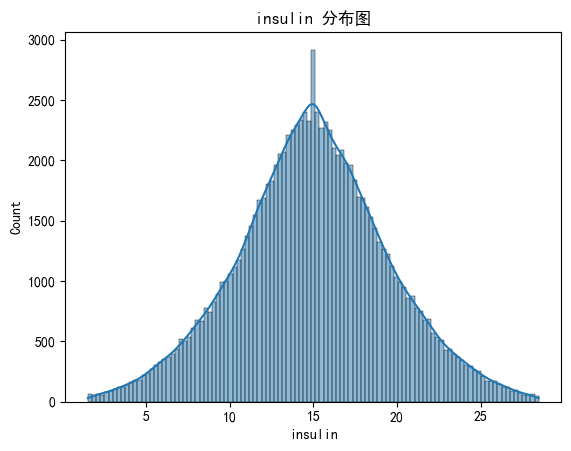

count    100000.000000
mean          6.987423
std           1.474725
min           3.000000
25%           5.986781
50%           6.998117
75%           8.004414
max          11.066937
Name: sleep_hours, dtype: float64


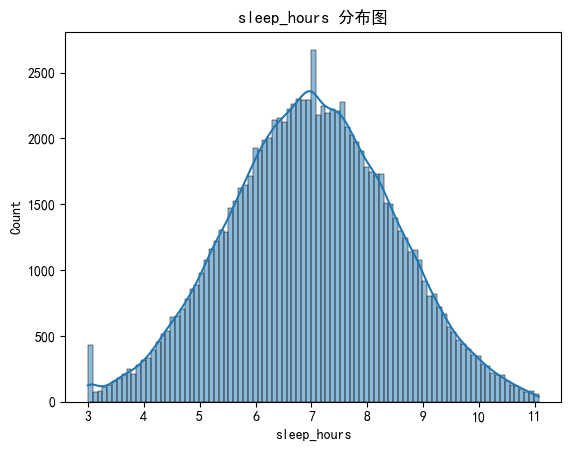

count    100000.000000
mean          8.003269
std           1.937305
min           2.598396
25%           6.671214
50%           8.004549
75%           9.336109
max          13.402927
Name: work_hours, dtype: float64


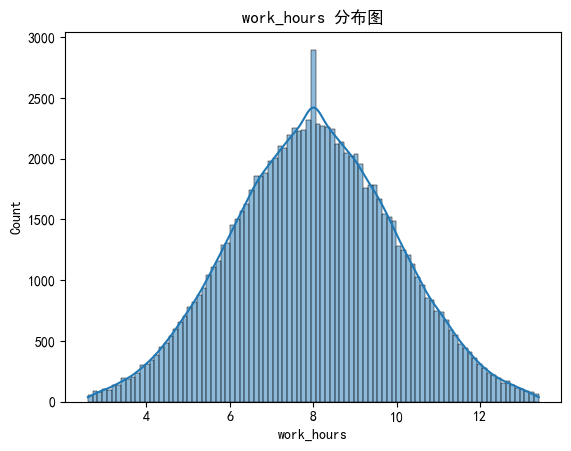

count    100000.000000
mean          3.017690
std           1.851302
min           0.000000
25%           1.633799
50%           2.971195
75%           4.304298
max           8.362492
Name: physical_activity, dtype: float64


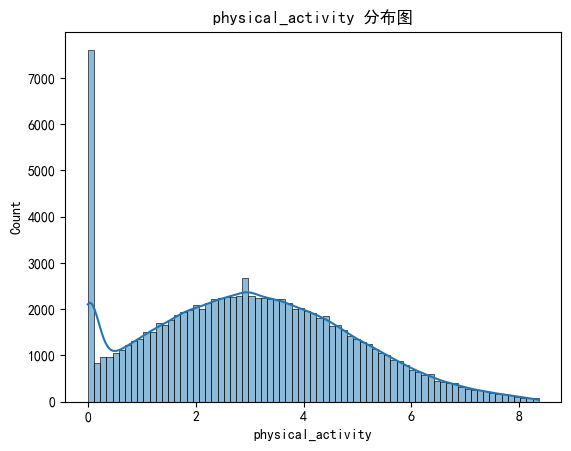

count    100000.000000
mean       6990.043471
std        2367.108816
min        1000.000000
25%        5446.363382
50%        7004.285450
75%        8556.448008
max       13773.038113
Name: daily_steps, dtype: float64


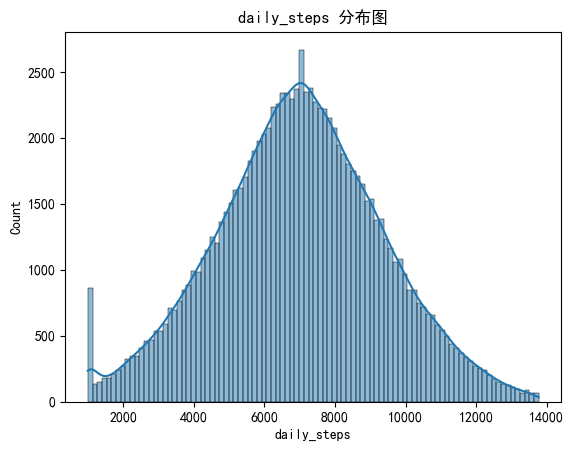

count    100000.000000
mean       2201.638895
std         386.855037
min        1124.783322
25%        1936.596743
50%        2200.992765
75%        2466.484939
max        3279.443961
Name: calorie_intake, dtype: float64


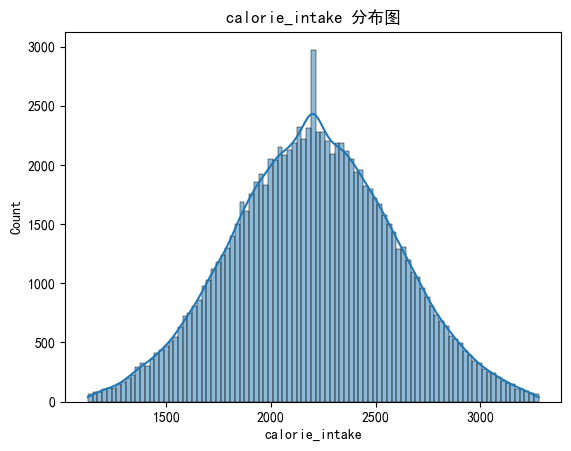

count    100000.000000
mean         60.066151
std          19.335342
min           6.060452
25%          46.731458
50%          60.047905
75%          73.283817
max         113.909670
Name: sugar_intake, dtype: float64


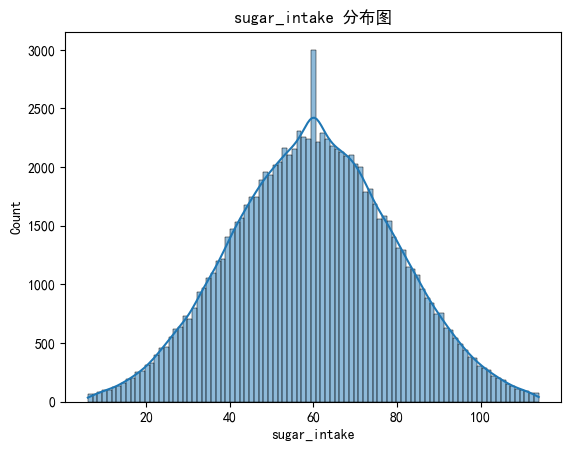

count    100000.000000
mean          1.999058
std           0.677528
min           0.500000
25%           1.532011
50%           2.000656
75%           2.465253
max           3.883588
Name: water_intake, dtype: float64


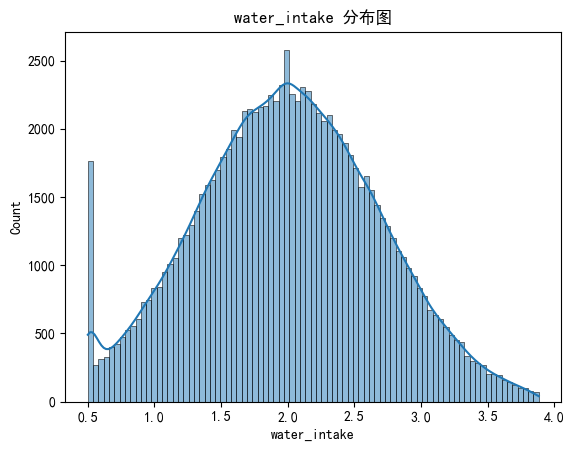

count    100000.000000
mean          5.991273
std           2.887393
min           0.000000
25%           3.971318
50%           5.991168
75%           7.990276
max          14.103687
Name: screen_time, dtype: float64


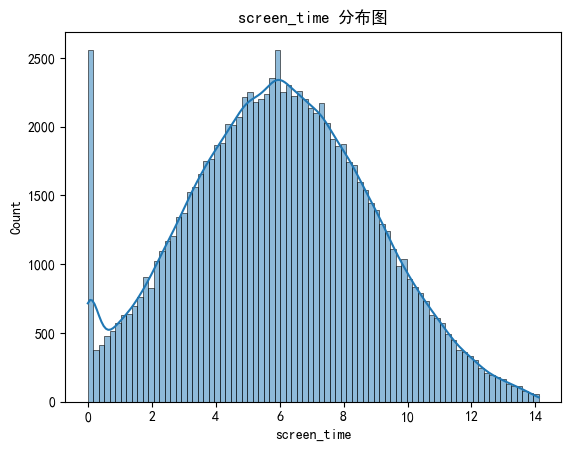

count    100000.000000
mean          4.991600
std           3.154997
min           0.000000
25%           2.000000
50%           5.000000
75%           8.000000
max          10.000000
Name: stress_level, dtype: float64


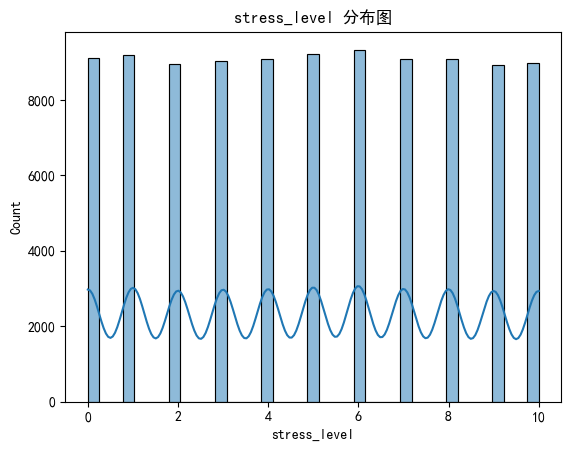

count    100000.000000
mean          5.004680
std           3.164228
min           0.000000
25%           2.000000
50%           5.000000
75%           8.000000
max          10.000000
Name: mental_health_score, dtype: float64


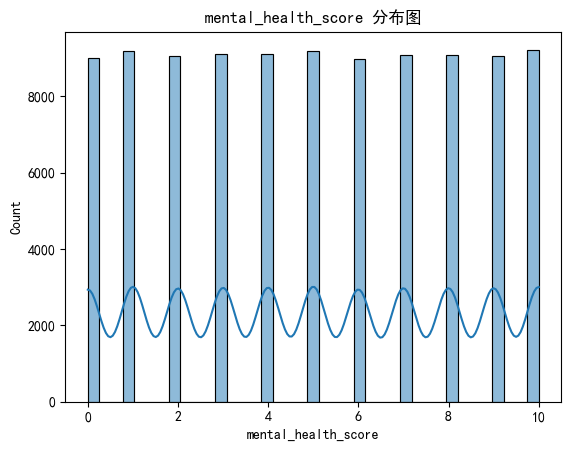

count    100000.000000
mean       4019.406953
std        1832.146795
min         500.000000
25%        2762.624430
50%        4004.601345
75%        5242.333528
max        9401.378393
Name: income, dtype: float64


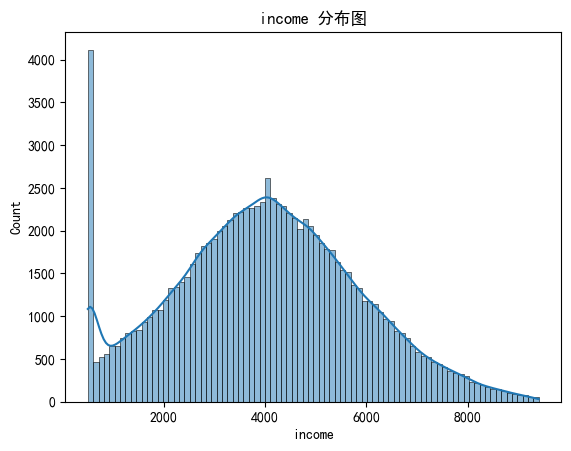

count    100000.000000
mean          2.998720
std           1.414786
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: meals_per_day, dtype: float64


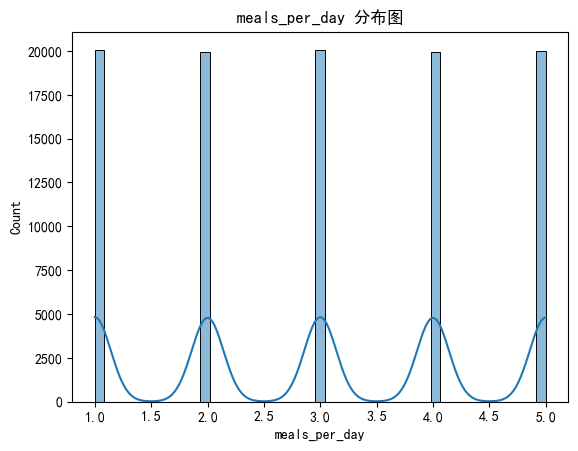

count    100000.000000
mean          0.015726
std           5.764489
min          -9.999895
25%          -4.980501
50%           0.015589
75%           5.008424
max           9.999966
Name: daily_supplement_dosage, dtype: float64


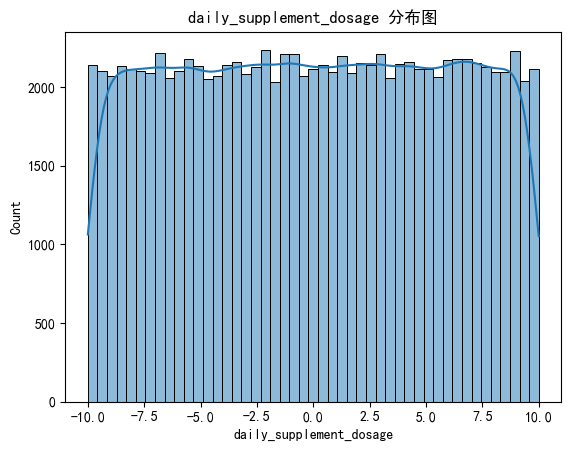

In [88]:
def summary_numeric(col):
    print(df[col].describe())
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} 分布图")
    plt.show()

for col in high_var_features:
    summary_numeric(col)

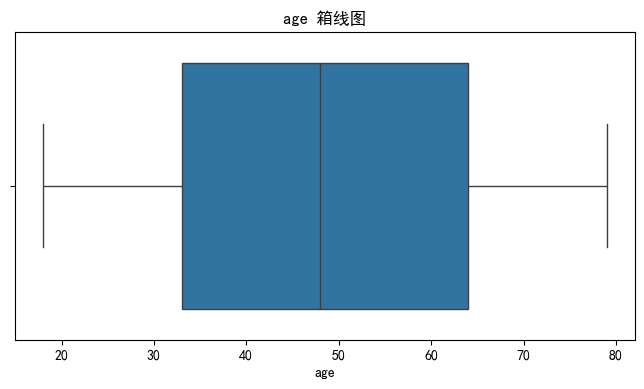

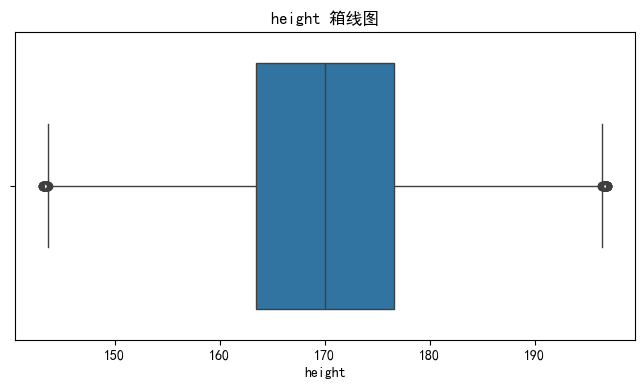

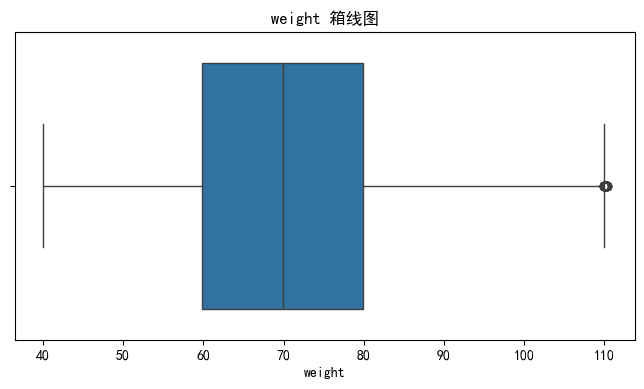

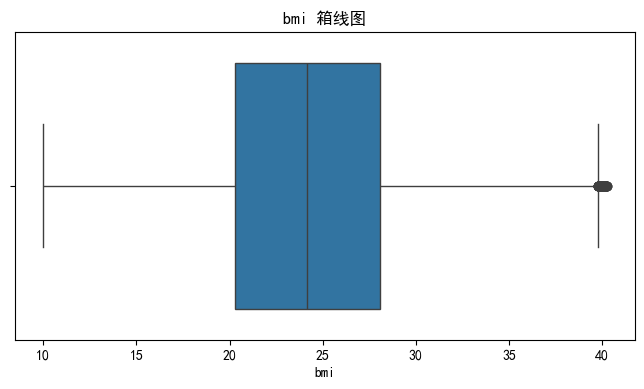

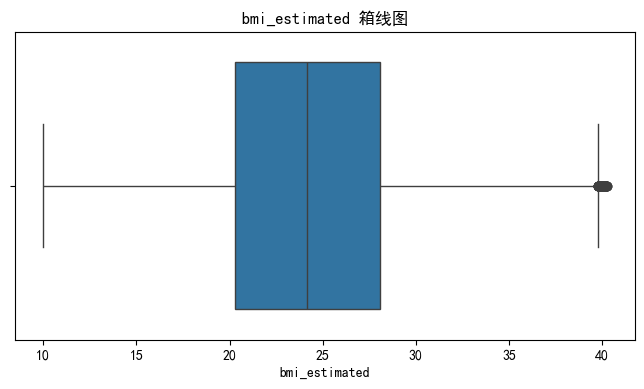

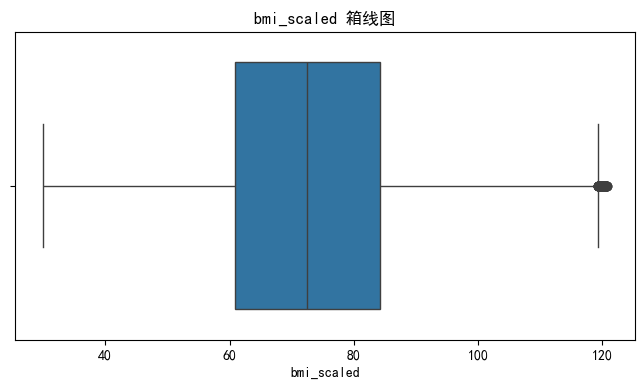

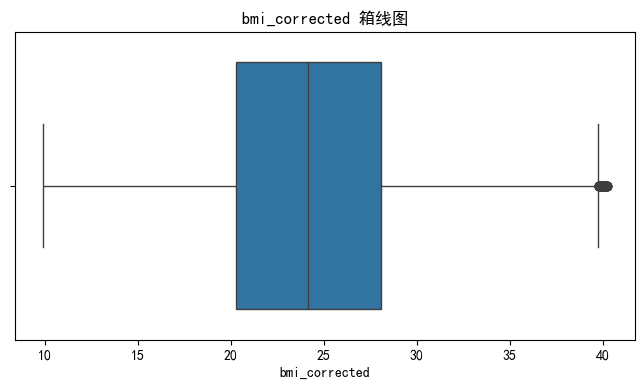

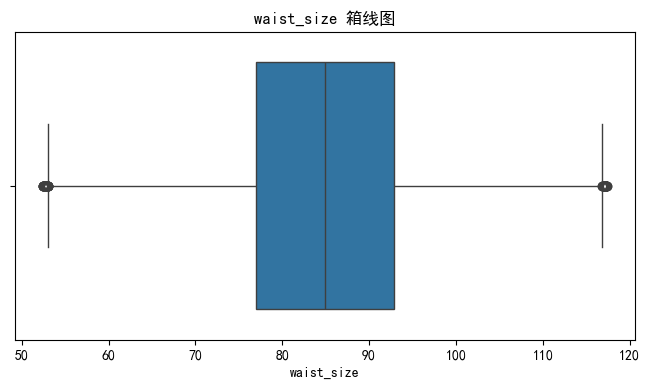

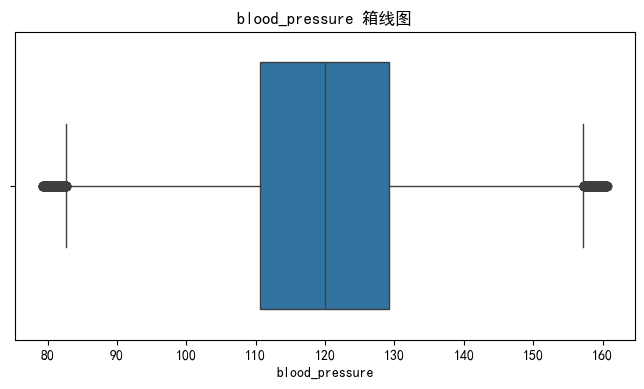

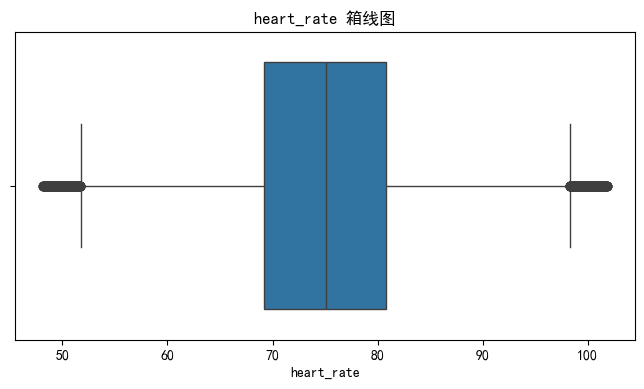

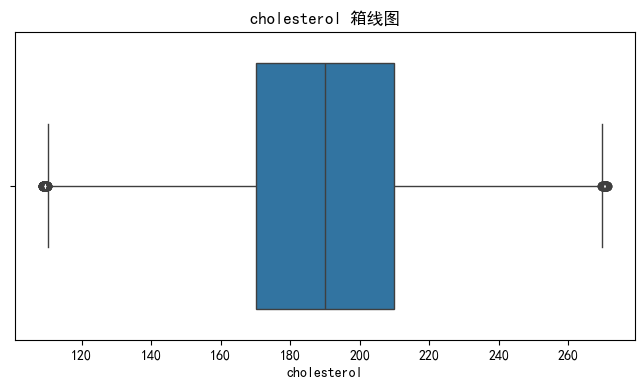

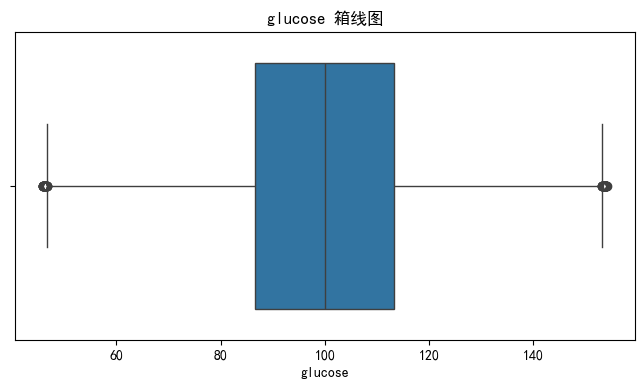

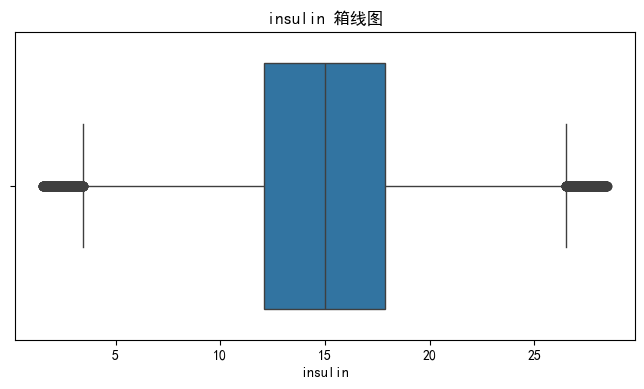

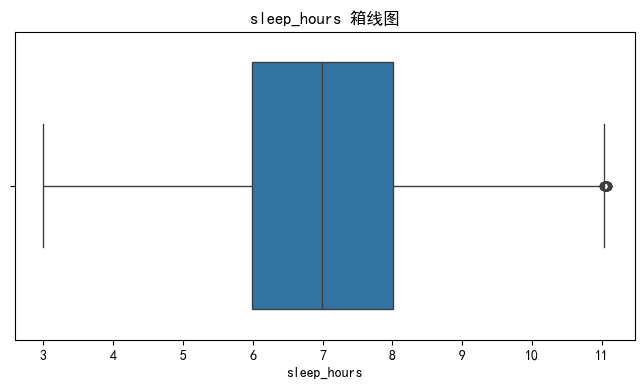

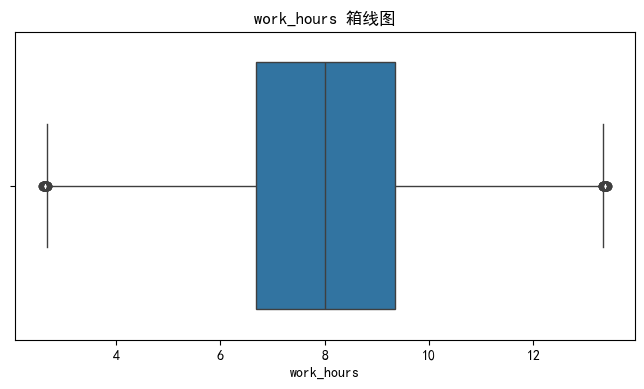

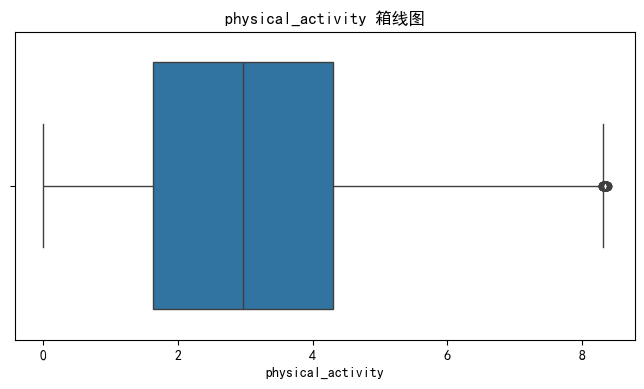

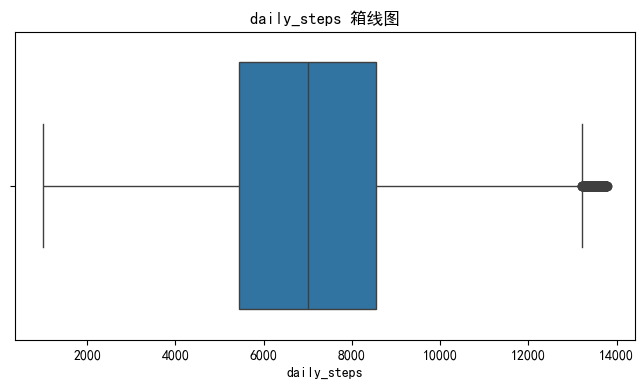

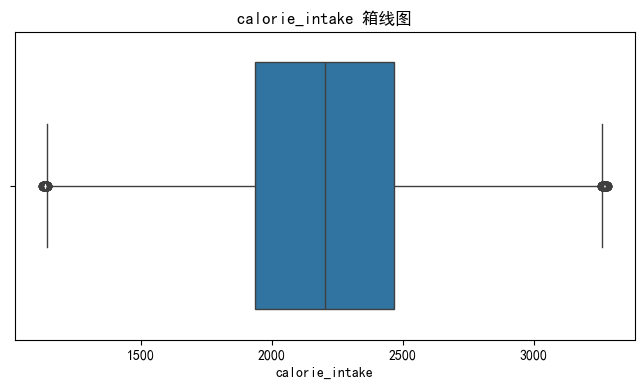

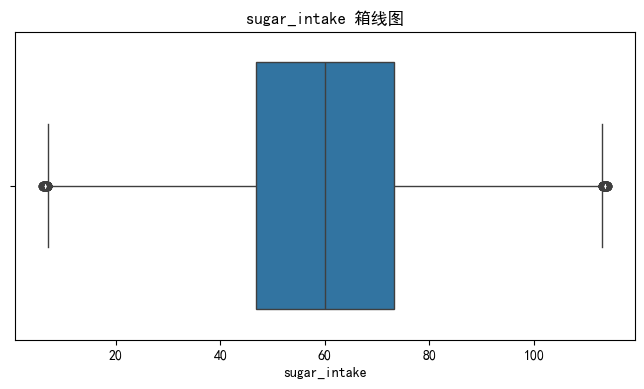

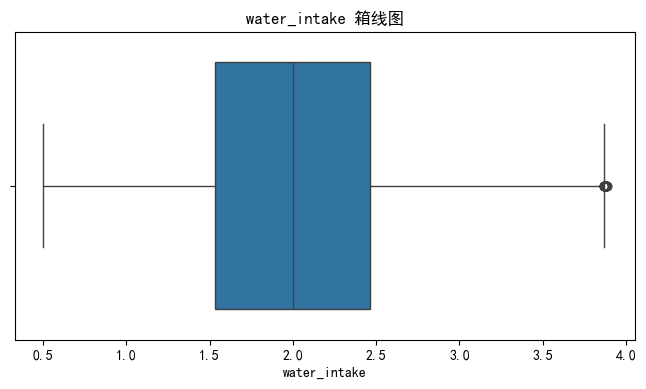

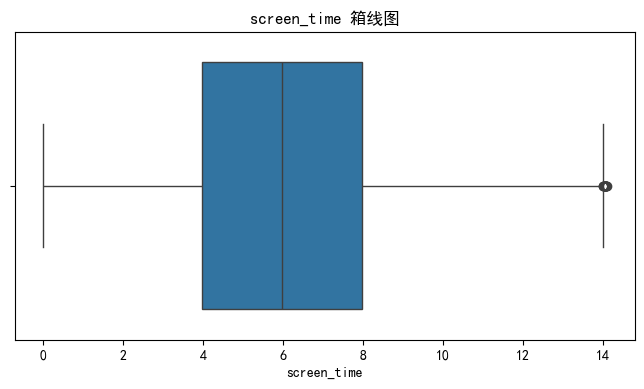

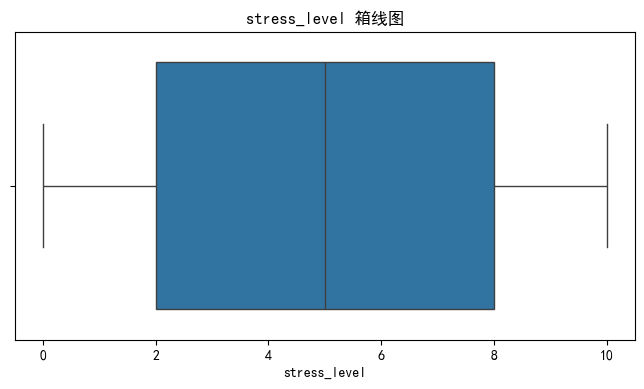

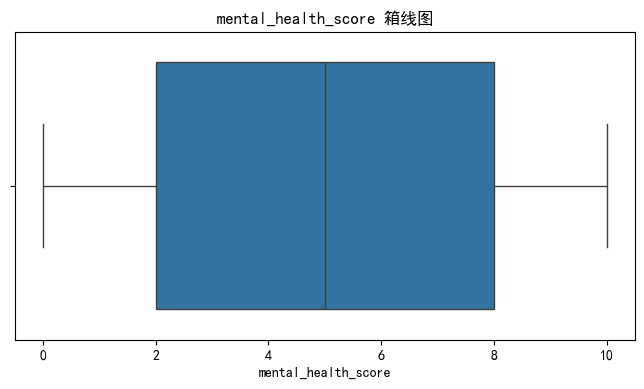

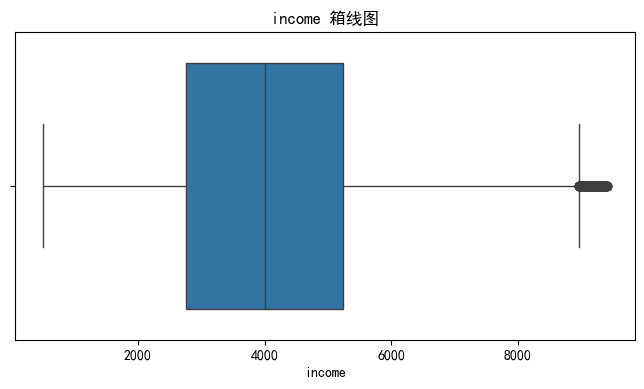

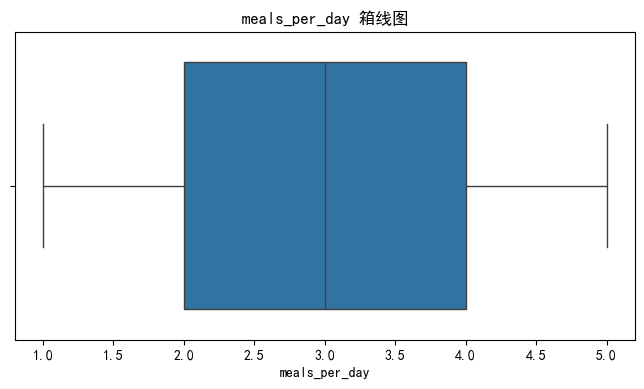

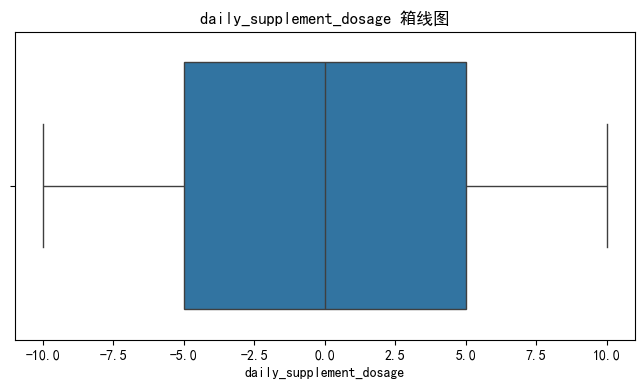

In [89]:
def boxplot_numeric(col):
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} 箱线图")
    plt.show()

for col in high_var_features:
    boxplot_numeric(col)

#### 分析分类特征

##### 查看唯一值

In [90]:
df[cat_cols].nunique()

gender                   2
sleep_quality            4
alcohol_consumption      2
smoking_level            3
mental_health_support    2
education_level          4
job_type                 6
occupation               6
diet_type                4
exercise_type            3
device_usage             3
healthcare_access        3
insurance                2
sunlight_exposure        3
caffeine_intake          2
family_history           2
pet_owner                2
dtype: int64

##### 编码

In [91]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

def encode_categorical_columns(df):
    """
    对分类列进行编码处理
    - 二分类变量：使用标签编码
    - 多分类变量：使用独热编码并转换为整数类型
    """

    label_encoder = LabelEncoder()

    for col in df.select_dtypes(include=['object', 'category']).columns:
        unique_vals = df[col].nunique()

        if unique_vals == 2:
            # 标签编码
            df[col] = label_encoder.fit_transform(df[col])
        elif unique_vals > 2:
            # 独热编码 + 从布尔值转换为整数
            dummies = pd.get_dummies(df[col], prefix=col).astype(int)
            df = pd.concat([df.drop(col, axis=1), dummies], axis=1)

    return df

In [92]:
df = encode_categorical_columns(df)

In [93]:
df.isnull().sum().sort_values(ascending=False).head()

gene_marker_flag       10474
age                        0
job_type_Healthcare        0
occupation_Doctor          0
occupation_Artist          0
dtype: int64

#### 对y进行编码

In [94]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [95]:
print("\n编码映射关系:")
for i, label in enumerate(le.classes_):
    print(f"{label} -> {i}")


编码映射关系:
diseased -> 0
healthy -> 1


### 预处理结果

In [96]:
X = df.drop('gene_marker_flag', axis=1)
# y = df['gene_marker_flag']

###  模型训练

#### 准备复用函数

In [97]:
# 混淆矩阵函数
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    plt.title('混淆矩阵')
    plt.show()

In [98]:
# 常用指标函数
def print_classification_report(y_true, y_pred):
    print("分类报告:\n", classification_report(y_true, y_pred))

In [99]:
# 绘制ROC曲线函数
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

def plot_roc_curve(y_true, y_pred_probs):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label='ROC曲线 (AUC = {:.2f})'.format(auc(fpr, tpr)))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('假阳性率')
    plt.ylabel('真阳性率')
    plt.title('ROC曲线')
    plt.legend()
    plt.show()

In [100]:
# 绘制PR曲线函数
from sklearn.metrics import precision_recall_curve

def plot_pr_curve(y_true, y_pred_probs):
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_probs)
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label='PR曲线 (AUC = {:.2f})'.format(auc(recall, precision)))
    plt.xlabel('召回率')
    plt.ylabel('精确率')
    plt.title('PR曲线')
    plt.legend()
    plt.show()

In [101]:
from sklearn.metrics import precision_score, recall_score


def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, cv=5):
    
    # 在测试集上评估
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    print(f'\n{model_name} 测试集评估结果:')
    print(f'准确率: {accuracy:.4f}')
    print(f'精确率: {precision:.4f}')
    print(f'召回率: {recall:.4f}')
    
    # 交叉验证评估
    print(f'\n{model_name} 交叉验证结果 (cv={cv}):')
    # 交叉验证准确率
    cv_accuracy = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    print(f'交叉验证准确率: {cv_accuracy.mean():.4f} (±{cv_accuracy.std():.4f})')
    
    # 交叉验证精确率
    cv_precision = cross_val_score(model, X_train, y_train, cv=cv, scoring='precision')
    print(f'交叉验证精确率: {cv_precision.mean():.4f} (±{cv_precision.std():.4f})')
    
    # 交叉验证召回率
    cv_recall = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall')
    print(f'交叉验证召回率: {cv_recall.mean():.4f} (±{cv_recall.std():.4f})')
    
    # 返回所有评估指标
    return {
        'test_accuracy': accuracy,
        'test_precision': precision,
        'test_recall': recall,
        'cv_accuracy': (cv_accuracy.mean(), cv_accuracy.std()),
        'cv_precision': (cv_precision.mean(), cv_precision.std()),
        'cv_recall': (cv_recall.mean(), cv_recall.std())
    }

#### XGBoost模型

In [139]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
pipe_xgb = Pipeline([
    ("scaler", StandardScaler()),
    ("XGB", xgb_model)
])
pipe_xgb.fit(X_train, y_train)
print("模型得分:", pipe_xgb.score(X_test, y_test))
print("召回率:", recall_score(y_test, pipe_xgb.predict(X_test)))
print("AUC评分：", roc_auc_score(y_test, pipe_xgb.predict_proba(X_test)[:, 1]))

模型得分: 0.69195
召回率: 0.9725881096475614
AUC评分： 0.4996211768637392


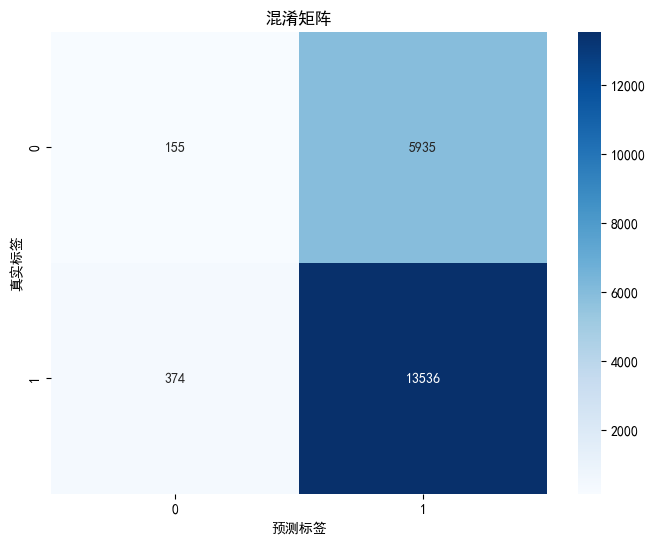

In [103]:
y_pred = pipe_xgb.predict(X_test)
plot_confusion_matrix(y_test, y_pred)

In [104]:
print_classification_report(y_test, y_pred)

分类报告:
               precision    recall  f1-score   support

           0       0.29      0.03      0.05      6090
           1       0.70      0.97      0.81     13910

    accuracy                           0.68     20000
   macro avg       0.49      0.50      0.43     20000
weighted avg       0.57      0.68      0.58     20000



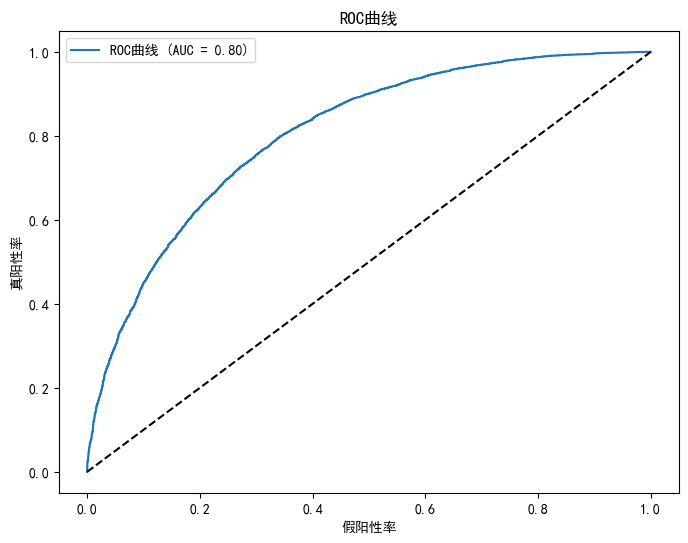

In [126]:
plot_roc_curve(y_test, pipe_xgb.predict_proba(X_test)[:, 1])

#### LightGBM模型

In [106]:
from sklearn.metrics import recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
lgbm_model = LGBMClassifier(random_state=42)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("LGBM", lgbm_model)
])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)
print("召回率:", recall_score(y_test, pipe.predict(X_test)))

[LightGBM] [Info] Number of positive: 56059, number of negative: 23941
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021475 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5843
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 72
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.700738 -> initscore=0.850812
[LightGBM] [Info] Start training from score 0.850812
召回率: 0.9995725886878473


In [107]:
X_train.isnull().sum().sort_values(ascending=False).head(10)

age                    0
occupation_Engineer    0
occupation_Doctor      0
occupation_Artist      0
job_type_Unemployed    0
job_type_Tech          0
job_type_Service       0
job_type_Office        0
job_type_Labor         0
job_type_Healthcare    0
dtype: int64

#### KNN

In [108]:
# K-近邻算法
import sklearn.neighbors as neighbors

knn_model = neighbors.KNeighborsClassifier()
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("KNN", knn_model)
])
pipe_knn.fit(X_train, y_train)
print("模型得分:", pipe_knn.score(X_test, y_test))
print("召回率:", recall_score(y_test, pipe_knn.predict(X_test)))

模型得分: 0.63125
召回率: 0.8316711782305172
